# Heston Stochastic Volatility Model: Interactive Analysis

This notebook provides interactive analysis and visualizations for the Heston model,
including simulation, pricing, and parameter sensitivity.

**Topics Covered:**
1. Heston Model Dynamics
2. Monte Carlo Simulation
3. Parameter Sensitivity (κ, θ, ξ, ρ)
4. Implied Volatility Smile
5. Greeks Analysis
6. Convergence to Black-Scholes

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
import sys
sys.path.insert(0, '../..')

# Project imports
from src.models.stochastic_volatility.heston import HestonParameters, HestonDynamics, HestonSimulation
from src.pricers.fx.heston_mc import FxHestonMcPricer, price_heston_european

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

## 1. Heston Model Dynamics

The Heston model specifies:

$$dS_t = (r - q) S_t dt + \sqrt{V_t} S_t dW_t^S$$
$$dV_t = \kappa(\theta - V_t) dt + \xi \sqrt{V_t} dW_t^V$$

with correlation $\text{Corr}(dW^S, dW^V) = \rho$

In [2]:
# Define Heston parameters
params = HestonParameters(
    kappa=2.0,    # Mean reversion speed
    theta=0.04,   # Long-term variance (20% vol)
    xi=0.3,       # Vol of vol
    v0=0.04,      # Initial variance (20% vol)
    rho=-0.7,     # Spot-variance correlation
)

print("Heston Parameters:")
print(f"  κ (mean reversion): {params.kappa}")
print(f"  θ (long-term var):  {params.theta} ({params.long_term_vol*100:.1f}% vol)")
print(f"  ξ (vol of vol):     {params.xi}")
print(f"  V₀ (initial var):   {params.v0} ({params.initial_vol*100:.1f}% vol)")
print(f"  ρ (correlation):    {params.rho}")
print(f"\nFeller Ratio: {params.feller_ratio:.2f}")
print(f"Feller Condition Satisfied: {params.feller_satisfied}")

Heston Parameters:
  κ (mean reversion): 2.0
  θ (long-term var):  0.04 (20.0% vol)
  ξ (vol of vol):     0.3
  V₀ (initial var):   0.04 (20.0% vol)
  ρ (correlation):    -0.7

Feller Ratio: 1.78
Feller Condition Satisfied: True


In [3]:
# Simulate sample paths
dynamics = HestonDynamics(params=params, drift=0.03)  # drift = r - q

sim = dynamics.simulate(
    spot0=100.0,
    maturity=2.0,
    n_paths=5,  # Few paths for visualization
    n_steps=500,
    scheme='full_truncation',
    seed=42,
    antithetic=False
)

print(f"Simulated {sim.n_paths} paths with {sim.n_steps} steps")
print(f"Maturity: {sim.maturity} years")

Simulated 5 paths with 500 steps
Maturity: 2.0 years


/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_16725/3791386667.py:28: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/joesstevens/PycharmProjects/QuantStrata/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


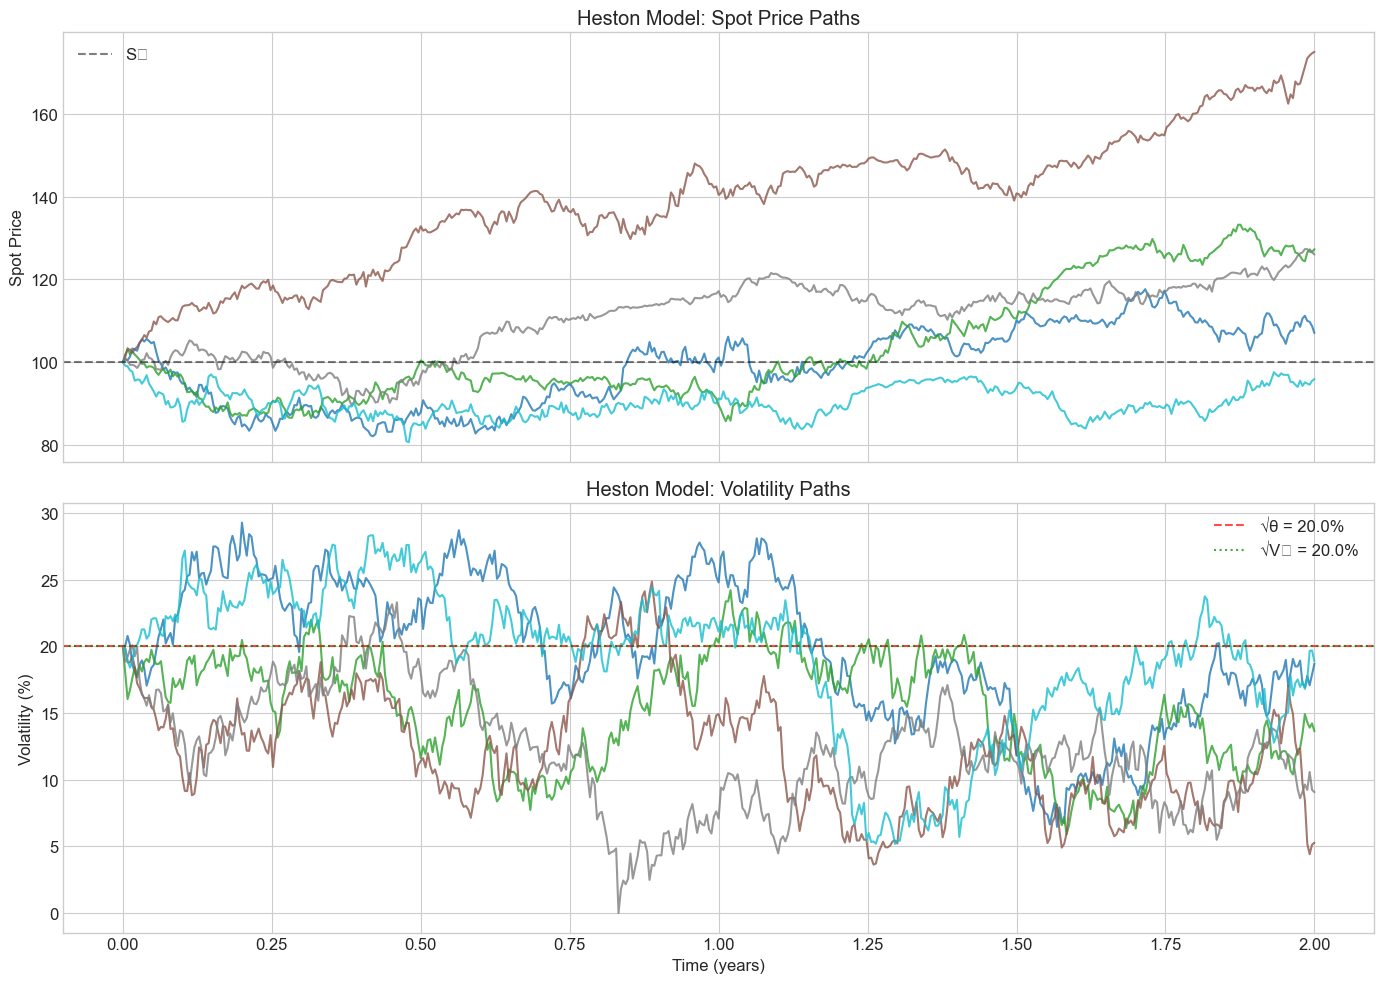


Note the mean reversion in volatility paths toward θ = 20%


In [4]:
# Visualize sample paths

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 1, sim.n_paths))

# Spot paths
for i in range(sim.n_paths):
    axes[0].plot(sim.times, sim.spot_paths[i], color=colors[i], alpha=0.8, linewidth=1.5)
axes[0].axhline(y=100, color='black', linestyle='--', alpha=0.5, label='S₀')
axes[0].set_ylabel('Spot Price')
axes[0].set_title('Heston Model: Spot Price Paths')
axes[0].legend()
axes[0].grid(True)

# Volatility paths (sqrt of variance)
for i in range(sim.n_paths):
    vol_path = np.sqrt(np.maximum(sim.variance_paths[i], 0)) * 100
    axes[1].plot(sim.times, vol_path, color=colors[i], alpha=0.8, linewidth=1.5)
axes[1].axhline(y=params.long_term_vol*100, color='red', linestyle='--', alpha=0.7, label=f'√θ = {params.long_term_vol*100:.1f}%')
axes[1].axhline(y=params.initial_vol*100, color='green', linestyle=':', alpha=0.7, label=f'√V₀ = {params.initial_vol*100:.1f}%')
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('Heston Model: Volatility Paths')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nNote the mean reversion in volatility paths toward θ = 20%")

## 2. Monte Carlo Pricing

Price European options using Monte Carlo simulation.

In [5]:
# Black-Scholes price for comparison
def bs_price(S, K, T, r, q, sigma, option_type='call'):
    """Black-Scholes price."""
    if T <= 0:
        return max(S - K, 0) if option_type == 'call' else max(K - S, 0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def implied_vol_from_price(price, S, K, T, r, q, option_type='call'):
    """Compute implied vol from price via Brent's method."""
    def objective(sigma):
        return bs_price(S, K, T, r, q, sigma, option_type) - price
    try:
        return brentq(objective, 0.001, 2.0)
    except:
        return np.nan

In [6]:
# Price ATM options

pricer = FxHestonMcPricer(n_paths=100000, n_steps=252, seed=42)

spot = 100.0
strike = 100.0
T = 1.0
r = 0.05
q = 0.02

# Heston prices
call_result = pricer.price_european(
    spot=spot, strike=strike, maturity=T,
    domestic_rate=r, foreign_rate=q,
    heston_params=params, option_type='call'
)

put_result = pricer.price_european(
    spot=spot, strike=strike, maturity=T,
    domestic_rate=r, foreign_rate=q,
    heston_params=params, option_type='put'
)

# BS prices with ATM vol
bs_vol = params.initial_vol
bs_call = bs_price(spot, strike, T, r, q, bs_vol, 'call')
bs_put = bs_price(spot, strike, T, r, q, bs_vol, 'put')

print("ATM Option Pricing Comparison:")
print(f"\n{'':>15} {'Heston MC':>15} {'BS (√V₀)':>15} {'95% CI':>20}")
print(f"{'Call Price':>15} {call_result.price:>15.4f} {bs_call:>15.4f} [{call_result.confidence_interval_95[0]:.4f}, {call_result.confidence_interval_95[1]:.4f}]")
print(f"{'Put Price':>15} {put_result.price:>15.4f} {bs_put:>15.4f} [{put_result.confidence_interval_95[0]:.4f}, {put_result.confidence_interval_95[1]:.4f}]")

# Compute implied vol
heston_implied_vol = implied_vol_from_price(call_result.price, spot, strike, T, r, q, 'call')
print(f"\nHeston ATM Implied Vol: {heston_implied_vol*100:.2f}%")
print(f"Input Vol (√V₀):       {params.initial_vol*100:.2f}%")

ATM Option Pricing Comparison:

                      Heston MC        BS (√V₀)               95% CI
     Call Price          9.0315          9.2270 [8.9611, 9.1019]
      Put Price          6.1058          6.3301 [6.0413, 6.1702]

Heston ATM Implied Vol: 19.48%
Input Vol (√V₀):       20.00%


## 3. Implied Volatility Smile

The Heston model generates implied volatility smiles through the correlation parameter ρ.

In [7]:
# Generate implied vol smile for different strikes

pricer_fast = FxHestonMcPricer(n_paths=50000, n_steps=100, seed=42)

strike_range = spot * np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
T_smile = 1.0

implied_vols = []
for K in strike_range:
    result = pricer_fast.price_european(
        spot=spot, strike=K, maturity=T_smile,
        domestic_rate=r, foreign_rate=q,
        heston_params=params, option_type='call'
    )
    iv = implied_vol_from_price(result.price, spot, K, T_smile, r, q, 'call')
    implied_vols.append(iv * 100 if not np.isnan(iv) else np.nan)

print("Strike | Implied Vol (%)")
print("-" * 25)
for K, iv in zip(strike_range, implied_vols):
    print(f"{K:>6.1f} | {iv:>10.2f}")

Strike | Implied Vol (%)
-------------------------
  85.0 |      21.74
  90.0 |      20.95
  95.0 |      20.20
 100.0 |      19.47
 105.0 |      18.77
 110.0 |      18.08
 115.0 |      17.43


/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_16725/1798819149.py:15: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


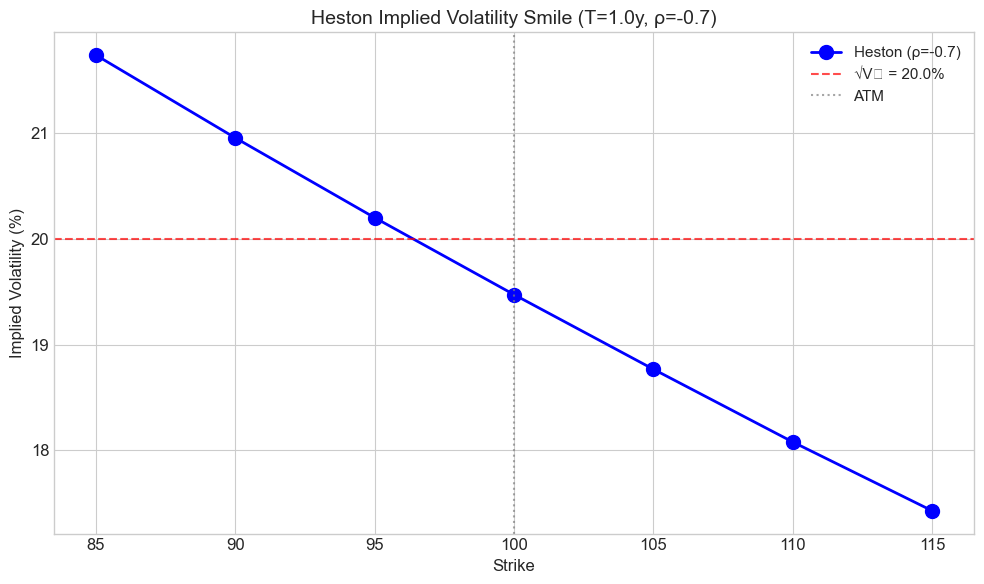


Key Observation:
Negative ρ creates DOWNWARD skew - higher vol at lower strikes.
This reflects the 'leverage effect': when spot falls, vol increases.


In [8]:
# Plot the implied vol smile

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strike_range, implied_vols, 'bo-', markersize=10, linewidth=2, label=f'Heston (ρ={params.rho})')
ax.axhline(y=params.initial_vol*100, color='red', linestyle='--', alpha=0.7, label=f'√V₀ = {params.initial_vol*100:.1f}%')
ax.axvline(x=spot, color='gray', linestyle=':', alpha=0.7, label='ATM')

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title(f'Heston Implied Volatility Smile (T={T_smile}y, ρ={params.rho})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("Negative ρ creates DOWNWARD skew - higher vol at lower strikes.")
print("This reflects the 'leverage effect': when spot falls, vol increases.")

## 4. Parameter Sensitivity: Correlation ρ

The correlation parameter ρ controls the skew direction and magnitude.

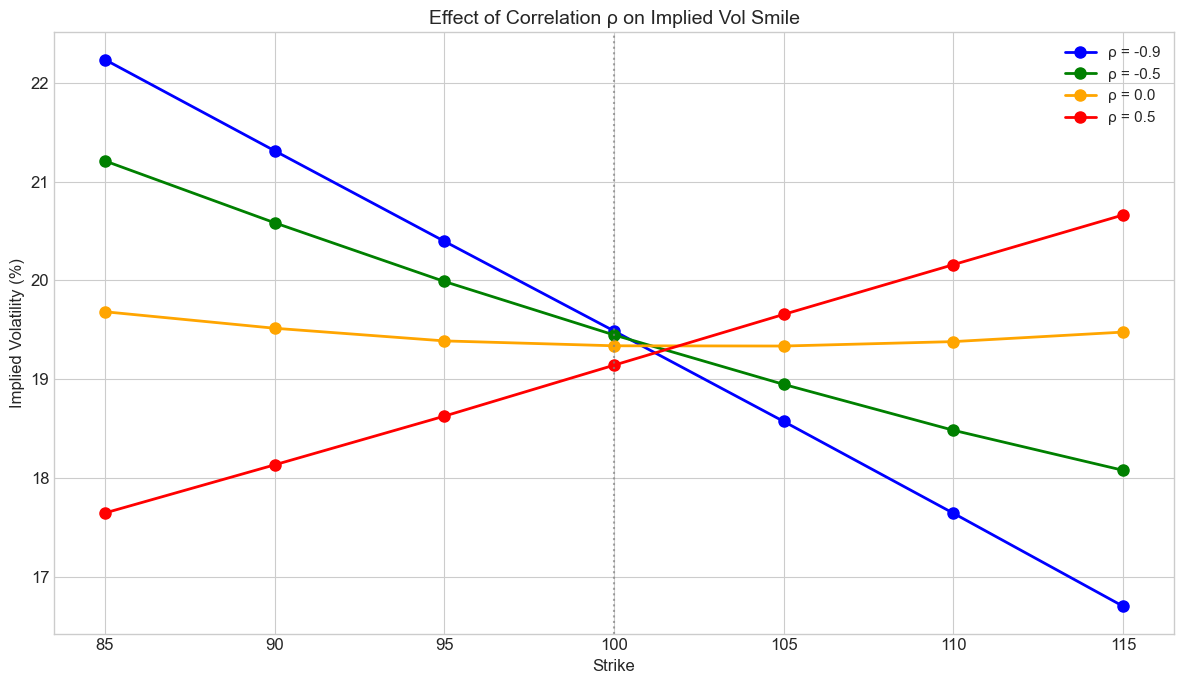


Correlation Effect:
  ρ < 0: Downward skew (equity-like, leverage effect)
  ρ = 0: Symmetric smile
  ρ > 0: Upward skew (less common)


In [9]:
# Compare smiles for different correlation values

rho_values = [-0.9, -0.5, 0.0, 0.5]
colors = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(12, 7))

for rho, color in zip(rho_values, colors):
    params_rho = HestonParameters(
        kappa=params.kappa, theta=params.theta, 
        xi=params.xi, v0=params.v0, rho=rho
    )
    
    ivols = []
    for K in strike_range:
        result = pricer_fast.price_european(
            spot=spot, strike=K, maturity=T_smile,
            domestic_rate=r, foreign_rate=q,
            heston_params=params_rho, option_type='call'
        )
        iv = implied_vol_from_price(result.price, spot, K, T_smile, r, q, 'call')
        ivols.append(iv * 100 if not np.isnan(iv) else np.nan)
    
    ax.plot(strike_range, ivols, 'o-', color=color, markersize=8, linewidth=2, label=f'ρ = {rho}')

ax.axvline(x=spot, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Effect of Correlation ρ on Implied Vol Smile', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

print("\nCorrelation Effect:")
print("  ρ < 0: Downward skew (equity-like, leverage effect)")
print("  ρ = 0: Symmetric smile")
print("  ρ > 0: Upward skew (less common)")

## 5. Parameter Sensitivity: Vol-of-Vol ξ

The vol-of-vol parameter ξ controls the smile curvature (convexity).

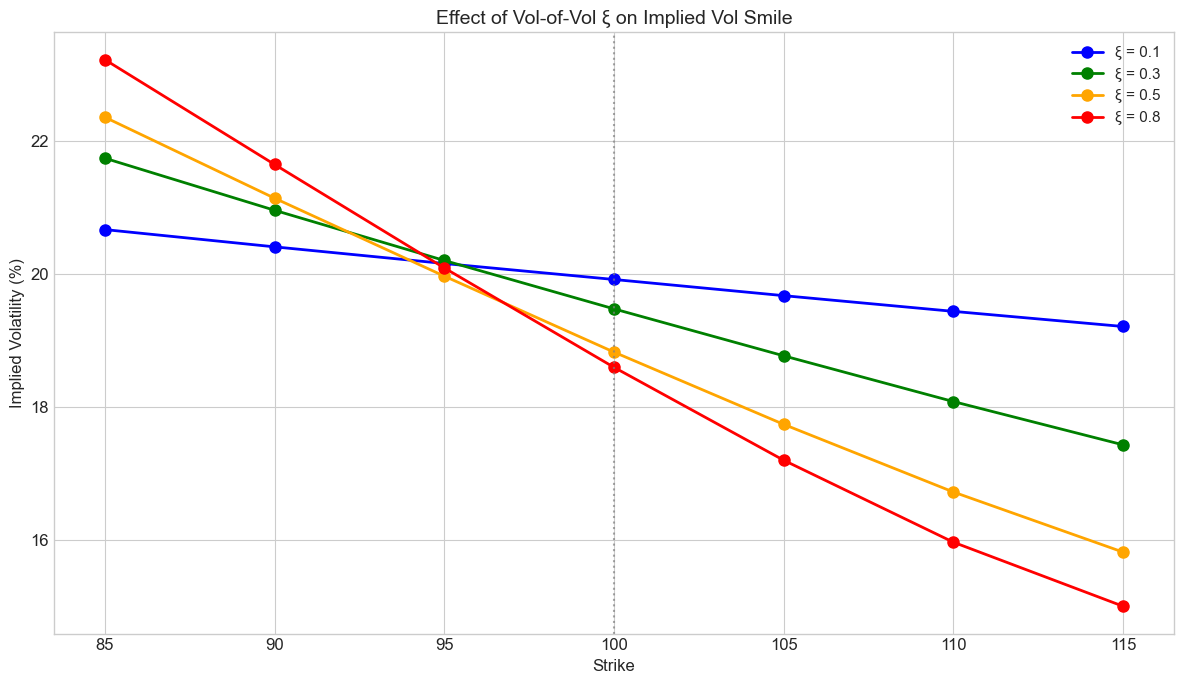


Vol-of-Vol Effect:
  Higher ξ → More pronounced smile curvature
  Higher ξ → Fatter tails in return distribution
  Note: Must maintain Feller condition 2κθ > ξ²


In [10]:
# Compare smiles for different vol-of-vol values

xi_values = [0.1, 0.3, 0.5, 0.8]
colors = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(12, 7))

for xi, color in zip(xi_values, colors):
    params_xi = HestonParameters(
        kappa=params.kappa, theta=params.theta, 
        xi=xi, v0=params.v0, rho=params.rho
    )
    
    ivols = []
    for K in strike_range:
        result = pricer_fast.price_european(
            spot=spot, strike=K, maturity=T_smile,
            domestic_rate=r, foreign_rate=q,
            heston_params=params_xi, option_type='call'
        )
        iv = implied_vol_from_price(result.price, spot, K, T_smile, r, q, 'call')
        ivols.append(iv * 100 if not np.isnan(iv) else np.nan)
    
    ax.plot(strike_range, ivols, 'o-', color=color, markersize=8, linewidth=2, label=f'ξ = {xi}')

ax.axvline(x=spot, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Effect of Vol-of-Vol ξ on Implied Vol Smile', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

print("\nVol-of-Vol Effect:")
print("  Higher ξ → More pronounced smile curvature")
print("  Higher ξ → Fatter tails in return distribution")
print("  Note: Must maintain Feller condition 2κθ > ξ²")

## 6. Variance Mean Reversion

The variance process mean-reverts to θ at rate κ.

/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_16725/2426000824.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


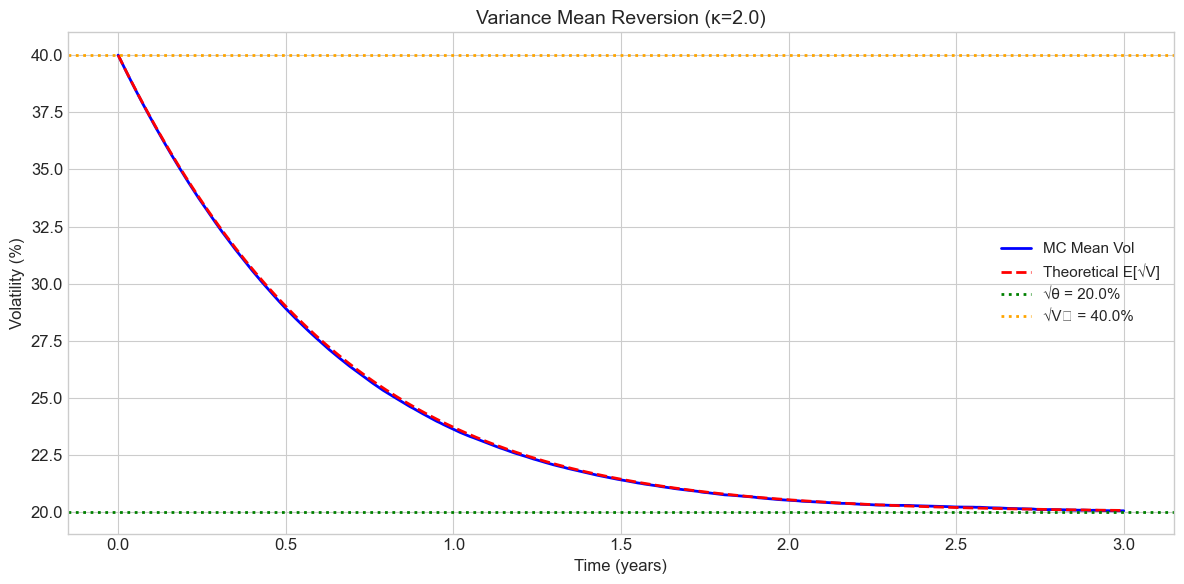


Mean reversion half-life: 0.35 years


In [11]:
# Visualize variance mean reversion

# Start with v0 different from theta
params_high_v0 = HestonParameters(
    kappa=2.0, theta=0.04, xi=0.2, v0=0.16, rho=-0.5  # V0 = 40% vol, theta = 20% vol
)

dynamics_mr = HestonDynamics(params=params_high_v0, drift=0.0)
sim_mr = dynamics_mr.simulate(
    spot0=100, maturity=3.0, n_paths=10000, n_steps=300, seed=42, antithetic=True
)

# Compute mean variance at each time step
mean_variance = np.mean(sim_mr.variance_paths, axis=0)
mean_vol = np.sqrt(mean_variance) * 100

# Theoretical expected variance
expected_var = [params_high_v0.expected_variance(t) for t in sim_mr.times]
expected_vol = np.sqrt(expected_var) * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sim_mr.times, mean_vol, 'b-', linewidth=2, label='MC Mean Vol')
ax.plot(sim_mr.times, expected_vol, 'r--', linewidth=2, label='Theoretical E[√V]')
ax.axhline(y=params_high_v0.long_term_vol*100, color='green', linestyle=':', 
           linewidth=2, label=f'√θ = {params_high_v0.long_term_vol*100:.1f}%')
ax.axhline(y=params_high_v0.initial_vol*100, color='orange', linestyle=':', 
           linewidth=2, label=f'√V₀ = {params_high_v0.initial_vol*100:.1f}%')

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title(f'Variance Mean Reversion (κ={params_high_v0.kappa})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"\nMean reversion half-life: {np.log(2)/params_high_v0.kappa:.2f} years")

## 7. Put-Call Parity Verification

Verify that the model satisfies put-call parity:
$$C - P = S e^{-qT} - K e^{-rT}$$

In [12]:
# Verify put-call parity

pricer_parity = FxHestonMcPricer(n_paths=100000, n_steps=200, seed=123)

call = pricer_parity.price_european(
    spot=spot, strike=strike, maturity=T,
    domestic_rate=r, foreign_rate=q,
    heston_params=params, option_type='call'
)

put = pricer_parity.price_european(
    spot=spot, strike=strike, maturity=T,
    domestic_rate=r, foreign_rate=q,
    heston_params=params, option_type='put'
)

# Theoretical parity value
parity_rhs = spot * np.exp(-q * T) - strike * np.exp(-r * T)
parity_lhs = call.price - put.price

print("Put-Call Parity Verification:")
print(f"\nCall Price:        {call.price:.6f}")
print(f"Put Price:         {put.price:.6f}")
print(f"C - P:             {parity_lhs:.6f}")
print(f"Se^(-qT) - Ke^(-rT): {parity_rhs:.6f}")
print(f"\nDifference:        {abs(parity_lhs - parity_rhs):.6f}")
print(f"Combined Std Error: {np.sqrt(call.std_error**2 + put.std_error**2):.6f}")

if abs(parity_lhs - parity_rhs) < 3 * np.sqrt(call.std_error**2 + put.std_error**2):
    print("\n✓ Put-Call Parity SATISFIED (within 3 std errors)")
else:
    print("\n✗ Put-Call Parity VIOLATED")

Put-Call Parity Verification:

Call Price:        9.083898
Put Price:         6.179932
C - P:             2.903967
Se^(-qT) - Ke^(-rT): 2.896925

Difference:        0.007042
Combined Std Error: 0.049056

✓ Put-Call Parity SATISFIED (within 3 std errors)


## 8. Key Takeaways

### Heston Model Summary:

1. **Two Factors**: Spot and variance are both stochastic
2. **Mean Reversion**: Variance reverts to θ at rate κ
3. **Feller Condition**: 2κθ > ξ² ensures variance stays positive
4. **Correlation**: ρ < 0 creates equity-like downward skew
5. **Vol-of-Vol**: ξ controls smile curvature

### When to Use Heston:
- Need to capture volatility smile
- Need stochastic volatility dynamics
- Pricing options sensitive to vol-of-vol

### Advantages:
- Generates realistic smiles
- Semi-analytic pricing (fast)
- Well-understood calibration

### Limitations:
- May not fit short-maturity smiles well
- Single stochastic factor for vol
- Feller constraint limits parameter space